In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print(df.shape)
df.head()


(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
#tien xu ly

In [5]:
#missing values
df["Age"].fillna(df["Age"].median(), inplace=True)
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)


/tmp/ipython-input-3719718651.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
/tmp/ipython-input-3719718651.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [6]:
# ending
df["Sex"] = df["Sex"].map({"male":0,"female":1})
df["Embarked"] = df["Embarked"].map({"S":0,"C":1,"Q":2})


In [7]:
features = ["Pclass","Sex","Age","SibSp","Parch","Fare","Embarked"]
X = df[features]
y = df["Survived"]


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [9]:
# huan luyen

In [10]:
# random forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)


In [11]:
# xgboost
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)


In [12]:
# danh gia
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred)
    }

rf_metrics = evaluate(y_test, rf_pred)
xgb_metrics = evaluate(y_test, xgb_pred)

rf_metrics, xgb_metrics


({'Accuracy': 0.7910447761194029,
  'Precision': 0.7570093457943925,
  'Recall': 0.7297297297297297,
  'F1-score': 0.7431192660550459},
 {'Accuracy': 0.8022388059701493,
  'Precision': 0.8222222222222222,
  'Recall': 0.6666666666666666,
  'F1-score': 0.736318407960199})

In [13]:
# feature importance

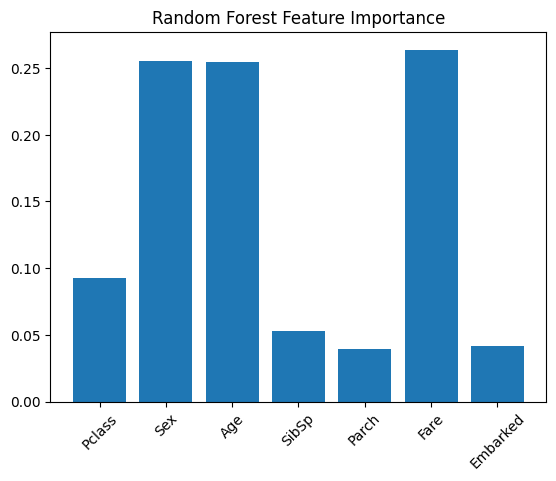

In [14]:
# random forest
import matplotlib.pyplot as plt

plt.bar(features, rf.feature_importances_)
plt.xticks(rotation=45)
plt.title("Random Forest Feature Importance")
plt.show()


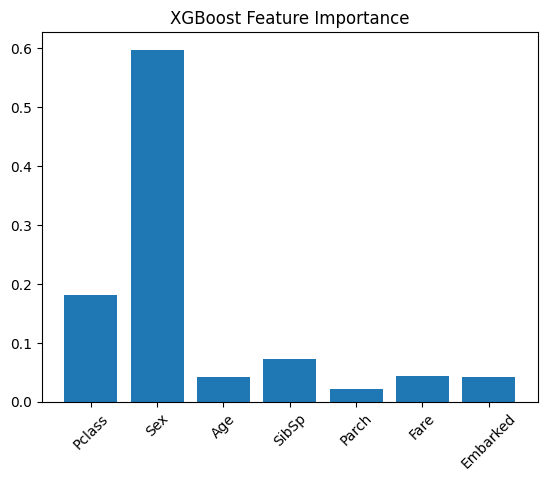

In [15]:
# xgboost
plt.bar(features, xgb_model.feature_importances_)
plt.xticks(rotation=45)
plt.title("XGBoost Feature Importance")
plt.show()



In [16]:
# Hyperparameter Tuning (gridSearchCV)

In [17]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

param_grid = {
    "n_estimators": [100, 150, 200],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 1.0],
    "colsample_bytree": [0.7, 1.0]
}

xgb_clf = xgb.XGBClassifier(
    random_state=42,
    objective="binary:logistic",
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)


Fitting 3 folds for each of 108 candidates, totalling 324 fits
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.7; total time=   0.0s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.7; total time=   0.0s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.7; total time=   0.0s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.0s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.0s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.0s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=150, subsample=0.7; total time=   0.0s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=150, subsample=0.7; total time=   0.0s
[CV] END 

In [18]:
#danh gia model
best_xgb = grid_search.best_estimator_

best_pred = best_xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, best_pred))
print("Precision:", precision_score(y_test, best_pred))
print("Recall:", recall_score(y_test, best_pred))
print("F1-score:", f1_score(y_test, best_pred))


Accuracy: 0.8022388059701493
Precision: 0.8085106382978723
Recall: 0.6846846846846847
F1-score: 0.7414634146341463


In [19]:
#stacking

In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_score
from mlxtend.classifier import StackingClassifier

clf1 = KNeighborsClassifier(n_neighbors=5)
clf2 = GaussianNB()
clf3 = LogisticRegression(max_iter=1000)


In [24]:
#LR
meta_lr = LogisticRegression(max_iter=1000)

stacking_lr = StackingClassifier(
    classifiers=[clf1, clf2, clf3],
    meta_classifier=meta_lr
)

stacking_lr.fit(X_train, y_train)

y_pred_lr = stacking_lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

scores_lr = cross_val_score(
    stacking_lr,
    X_train,
    y_train,
    cv=3,
    scoring='accuracy'
)

print("CV Accuracy (LR Meta): %.3f (+/- %.3f)" %
      (scores_lr.mean(), scores_lr.std()))


Accuracy: 0.8059701492537313
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       157
           1       0.78      0.75      0.76       111

    accuracy                           0.81       268
   macro avg       0.80      0.80      0.80       268
weighted avg       0.81      0.81      0.81       268

CV Accuracy (LR Meta): 0.783 (+/- 0.036)


In [25]:
#RF
meta_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

stacking_rf = StackingClassifier(
    classifiers=[clf1, clf2, clf3],
    meta_classifier=meta_rf
)

stacking_rf.fit(X_train, y_train)

y_pred_rf = stacking_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

scores_rf = cross_val_score(
    stacking_rf,
    X_train,
    y_train,
    cv=3,
    scoring='accuracy'
)

print("CV Accuracy (RF Meta): %.3f (+/- %.3f)" %
      (scores_rf.mean(), scores_rf.std()))


Accuracy: 0.7798507462686567
              precision    recall  f1-score   support

           0       0.83      0.78      0.81       157
           1       0.72      0.77      0.74       111

    accuracy                           0.78       268
   macro avg       0.77      0.78      0.78       268
weighted avg       0.78      0.78      0.78       268

CV Accuracy (RF Meta): 0.738 (+/- 0.032)
